# importing libraries

In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder

# loading Data

In [229]:
data = pd.read_csv('Mall_Customers.csv')

# Data Exolore

In [230]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [231]:
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [232]:
data.shape

(200, 5)

In [233]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [234]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [235]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [236]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [237]:
data.duplicated().sum()

np.int64(0)

In [238]:

data = data.drop(['CustomerID', 'Gender'], axis=1)

In [239]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data[['Annual Income (k$)','Spending Score (1-100)','Age']])

In [240]:
data_scaled = pd.DataFrame(
    data_scaled,
    columns=[  'Annual Income (k$)', 'Spending Score (1-100)','Age']
)


In [241]:
data_scaled.head()

,Annual Income (k$),Spending Score (1-100),Age
0,-1.738999,-0.434801,-1.424569
1,-1.738999,1.195704,-1.281035
2,-1.700830,-1.715913,-1.352802
3,-1.700830,1.040418,-1.137502
4,-1.662660,-0.395980,-0.563369


In [242]:
wcss = []
k_range = range(1,9)
for k in k_range:
  kmean = KMeans(n_clusters=k)
  kmean.fit(data_scaled)
  wcss.append(kmean.inertia_)

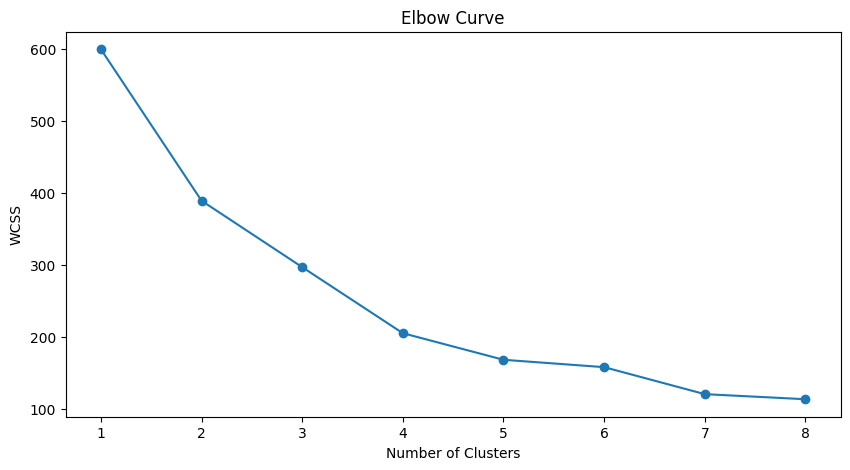

In [243]:
plt.figure(figsize=(10,5))
plt.plot(k_range,wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.show()

In [255]:
kmeans = KMeans(n_clusters=3)
data["Cluster"] = kmeans.fit_predict(data_scaled)

In [256]:
score = silhouette_score(data_scaled, data["Cluster"])
print(score)

0.3502714356255855


In [259]:
fig = px.scatter_3d(
    data_frame=data,
    x='Age',
    y='Annual Income (k$)',
    z='Spending Score (1-100)',
    color='Cluster',
    title='3D Customer Segmentation using K-Means',
    opacity=0.8,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()